目标数据处理

In [11]:
import os
import glob
import shutil
import random
import xml.etree.ElementTree as ET
from tqdm import tqdm

# ================= 1. 请在这里仔细修改路径 =================
# 根目录 (你的原始数据解压位置)
ROOT_DIR = "/root/autodl-tmp/NEU-DET" 

# 假设你的目录结构是分开的，如果是在同一个文件夹，就把这两个改成一样的路径
# 常见结构可能是: ROOT_DIR/ANNOTATIONS 和 ROOT_DIR/IMAGES
XML_DIR = os.path.join(ROOT_DIR, "ANNOTATIONS")  # 存放 .xml 的文件夹
IMG_DIR = os.path.join(ROOT_DIR, "IMAGES")       # 存放 .jpg/.bmp 的文件夹

# 输出路径
OUTPUT_PATH = "/root/autodl-tmp/exp1/NEU_DET_YOLO"

# 类别定义 (NEU-DET 标准6类)
CLASSES = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
# ==========================================================

def convert(size, box):
    """将 xml 的 xyxy 转换为 yolo 的 xywh 归一化格式"""
    dw = 1./size[0]
    dh = 1./size[1]
    x = (box[0] + box[1])/2.0
    y = (box[2] + box[3])/2.0
    w = box[1] - box[0]
    h = box[3] - box[2]
    return (x*dw, y*dh, w*dw, h*dh)

def check_paths():
    """路径自检函数"""
    print(f"正在检查路径配置...")
    print(f"   XML 目录: {XML_DIR}")
    print(f"   IMG 目录: {IMG_DIR}")
    
    if not os.path.exists(XML_DIR):
        print(f"错误: XML目录不存在! 请检查路径。")
        return False
    if not os.path.exists(IMG_DIR):
        print(f"错误: 图片目录不存在! 请检查路径。")
        return False
        
    # 尝试列出文件
    xmls = glob.glob(os.path.join(XML_DIR, "*.xml"))
    imgs = glob.glob(os.path.join(IMG_DIR, "*.*")) # 匹配所有后缀
    
    print(f"   检测到 XML 文件数: {len(xmls)}")
    print(f"   检测到 图片 文件数: {len(imgs)}")
    
    if len(xmls) == 0:
        print("警告: 没有找到XML文件，请确认文件夹里是否有 .xml 后缀的文件。")
        return False
    
    return True

def main():
    # 1. 运行前检查
    if not check_paths():
        return

    # 2. 清理旧数据
    if os.path.exists(OUTPUT_PATH):
        shutil.rmtree(OUTPUT_PATH)
    
    # 创建目录结构
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(OUTPUT_PATH, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(OUTPUT_PATH, 'labels', split), exist_ok=True)

    # 3. 匹配 XML 和 图片
    xml_list = glob.glob(os.path.join(XML_DIR, "*.xml"))
    pairs = []
    
    print("正在匹配 XML 和 图片...")
    for xml_file in xml_list:
        file_name = os.path.splitext(os.path.basename(xml_file))[0]
        
        # 尝试寻找对应的图片 (支持 jpg, bmp, png)
        found_img = None
        for ext in ['.jpg', '.bmp', '.png', '.JPG', '.BMP']:
            probe_path = os.path.join(IMG_DIR, file_name + ext)
            if os.path.exists(probe_path):
                found_img = probe_path
                break
        
        if found_img:
            pairs.append((xml_file, found_img))
    
    print(f"成功匹配 {len(pairs)} 对数据 (丢弃 {len(xml_list) - len(pairs)} 个无图 XML)")
    if len(pairs) == 0:
        print("错误: 匹配数量为0，请检查图片和XML的文件名是否一致！")
        return

    # 4. 随机划分 8:1:1
    random.seed(42)
    random.shuffle(pairs)
    total = len(pairs)
    n_train = int(total * 0.8)
    n_val = int(total * 0.1)
    
    splits = {
        'train': pairs[:n_train],
        'val':   pairs[n_train : n_train + n_val],
        'test':  pairs[n_train + n_val:]
    }

    # 5. 执行转换
    for split_name, data_list in splits.items():
        print(f"🚀 处理 {split_name} 集 ({len(data_list)} 张)...")
        for xml_path, img_path in tqdm(data_list):
            # 复制图片
            file_name = os.path.basename(img_path)
            dst_img_path = os.path.join(OUTPUT_PATH, 'images', split_name, file_name)
            shutil.copy(img_path, dst_img_path)
            
            # 解析 XML 转 Label
            try:
                tree = ET.parse(xml_path)
                root = tree.getroot()
                size = root.find('size')
                w = int(size.find('width').text)
                h = int(size.find('height').text)
                
                txt_content = []
                for obj in root.iter('object'):
                    cls_name = obj.find('name').text
                    if cls_name in CLASSES:
                        cls_id = CLASSES.index(cls_name)
                        xmlbox = obj.find('bndbox')
                        b = (float(xmlbox.find('xmin').text), float(xmlbox.find('xmax').text), 
                             float(xmlbox.find('ymin').text), float(xmlbox.find('ymax').text))
                        bb = convert((w, h), b)
                        txt_content.append(f"{cls_id} {' '.join(f'{x:.6f}' for x in bb)}")
                
                # 写入 txt
                txt_name = os.path.splitext(file_name)[0] + ".txt"
                with open(os.path.join(OUTPUT_PATH, 'labels', split_name, txt_name), 'w') as f:
                    f.write('\n'.join(txt_content))
            except Exception as e:
                print(f"解析错误 {xml_path}: {e}")

    # 6. 生成 YAML
    yaml_content = f"""path: {OUTPUT_PATH}
train: images/train
val: images/val
test: images/test

nc: {len(CLASSES)}
names: {CLASSES}
"""
    with open(os.path.join(OUTPUT_PATH, "neu_det.yaml"), 'w') as f:
        f.write(yaml_content)

    print("\n全部完成！")
    print(f"数据集已保存在: {OUTPUT_PATH}")
    print(f"配置文件路径: {os.path.join(OUTPUT_PATH, 'neu_det.yaml')}")

if __name__ == "__main__":
    main()

正在检查路径配置...
   XML 目录: /root/autodl-tmp/NEU-DET/ANNOTATIONS
   IMG 目录: /root/autodl-tmp/NEU-DET/IMAGES
   检测到 XML 文件数: 1800
   检测到 图片 文件数: 1800
正在匹配 XML 和 图片...
成功匹配 1800 对数据 (丢弃 0 个无图 XML)
🚀 处理 train 集 (1440 张)...


100%|██████████| 1440/1440 [00:00<00:00, 2323.60it/s]


🚀 处理 val 集 (180 张)...


100%|██████████| 180/180 [00:00<00:00, 1762.24it/s]


🚀 处理 test 集 (180 张)...


100%|██████████| 180/180 [00:00<00:00, 1722.92it/s]


全部完成！
数据集已保存在: /root/autodl-tmp/exp1/NEU_DET_YOLO
配置文件路径: /root/autodl-tmp/exp1/NEU_DET_YOLO/neu_det.yaml


目标数据查看

In [5]:
import pandas as pd
import numpy as np
import os
import cv2
from tqdm import tqdm

# ================= 配置区域 =================
# 请修改为你 AutoDL 里的实际路径
ROOT_DIR = "/root/autodl-tmp/severstal-steel"
IMG_DIR = os.path.join(ROOT_DIR, "train_images")
CSV_PATH = os.path.join(ROOT_DIR, "train.csv")

# 输出路径
OUTPUT_LABEL_DIR = os.path.join(ROOT_DIR, "labels/train")
os.makedirs(OUTPUT_LABEL_DIR, exist_ok=True)
# ===========================================

def rle2mask(mask_rle, shape=(256, 1600)):
    """
    解码 RLE 掩码
    """
    if pd.isna(mask_rle) or mask_rle == '': 
        return None
    
    s = mask_rle.split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0:][::2], s[1:][::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape, order='F')

def mask2bbox(mask):
    """
    从掩码计算外接矩形框 (XYXY)
    """
    if mask is None:
        return None
    pos = np.where(mask)
    if len(pos[0]) == 0:
        return None
    xmin = np.min(pos[1])
    xmax = np.max(pos[1])
    ymin = np.min(pos[0])
    ymax = np.max(pos[0])
    return [xmin, ymin, xmax, ymax]

def process():
    if not os.path.exists(CSV_PATH):
        print(f"❌ 错误: 找不到文件 {CSV_PATH}")
        return

    print("正在读取 CSV...")
    df = pd.read_csv(CSV_PATH)
    
    # 打印前几行看看，确保列名对上了
    print("CSV 列名:", df.columns.tolist())
    print(df.head())

    # 建立一个字典来聚合一张图的所有标注
    img_dict = {} 
    
    print("正在解析数据...")
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        rle = row['EncodedPixels']
        
        # 如果 RLE 为空，说明没有缺陷，跳过
        if pd.isna(rle) or rle == '':
            continue
            
        # 【修正点】直接读取列
        img_name = row['ImageId']
        class_id_raw = int(row['ClassId'])
        
        # Severstal 类别是 1,2,3,4 -> YOLO 需要 0,1,2,3
        class_id = class_id_raw - 1 
        
        if img_name not in img_dict:
            img_dict[img_name] = []
        
        img_dict[img_name].append({'class_id': class_id, 'rle': rle})

    print(f"共有 {len(img_dict)} 张图片包含缺陷。开始生成 YOLO 标签...")
    
    # 确保输出目录存在
    if not os.path.exists(OUTPUT_LABEL_DIR):
        os.makedirs(OUTPUT_LABEL_DIR)

    for img_name, annotations in tqdm(img_dict.items()):
        txt_path = os.path.join(OUTPUT_LABEL_DIR, img_name.replace('.jpg', '.txt'))
        
        # 图片尺寸 Severstal 固定为 (256, 1600)
        H, W = 256, 1600 
        
        valid_boxes = []
        
        for ann in annotations:
            mask = rle2mask(ann['rle'], shape=(H, W))
            bbox = mask2bbox(mask) # [xmin, ymin, xmax, ymax]
            
            if bbox is not None:
                # 归一化 (YOLO格式: class x_center y_center w h)
                xmin, ymin, xmax, ymax = bbox
                
                x_center = ((xmin + xmax) / 2) / W
                y_center = ((ymin + ymax) / 2) / H
                w = (xmax - xmin) / W
                h = (ymax - ymin) / H
                
                cls = ann['class_id']
                valid_boxes.append(f"{cls} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")
        
        # 写入 txt
        if valid_boxes:
            with open(txt_path, 'w') as f:
                f.write('\n'.join(valid_boxes))

if __name__ == '__main__':
    process()
    print("✅ 转换完成！")

正在读取 CSV...
CSV 列名: ['ImageId', 'ClassId', 'EncodedPixels']
         ImageId  ClassId                                      EncodedPixels
0  0002cc93b.jpg        1  29102 12 29346 24 29602 24 29858 24 30114 24 3...
1  0007a71bf.jpg        3  18661 28 18863 82 19091 110 19347 110 19603 11...
2  000a4bcdd.jpg        1  37607 3 37858 8 38108 14 38359 20 38610 25 388...
3  000f6bf48.jpg        4  131973 1 132228 4 132483 6 132738 8 132993 11 ...
4  0014fce06.jpg        3  229501 11 229741 33 229981 55 230221 77 230468...
正在解析数据...


100%|██████████| 7095/7095 [00:00<00:00, 24896.17it/s]


共有 6666 张图片包含缺陷。开始生成 YOLO 标签...


100%|██████████| 6666/6666 [00:13<00:00, 481.20it/s]

✅ 转换完成！


源域数据处理

In [13]:
import os
import shutil
import pandas as pd
import numpy as np
import cv2
from tqdm import tqdm

# ================= 1. 配置区域 (请仔细核对) =================
# 原始 CSV 文件路径
RAW_CSV_PATH = "/root/autodl-tmp/severstal/train.csv"

# 原始图片文件夹路径
RAW_IMG_DIR = "/root/autodl-tmp/severstal/train_images"

# 输出路径 (为了规整，建议和 NEU-DET 放在同一级目录)
OUTPUT_PATH = "/root/autodl-tmp/exp1/SEVERSTAL_YOLO"

# Severstal 的图片固定尺寸 (用于归一化)
IMG_W = 1600
IMG_H = 256
# ===========================================================

def rle2bbox(rle, shape=(1600, 256)):
    """解码 RLE 掩码并转换为 YOLO 格式 bbox"""
    try:
        # RLE 解码
        runs = np.array([int(x) for x in rle.split()])
        starts, lengths = runs[0::2], runs[1::2]
        mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)
        for s, l in zip(starts, lengths):
            mask[s - 1 : s + l - 1] = 1
        mask = mask.reshape(shape, order='F') # Fortran Order

        # 提取轮廓
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        bboxes = []
        for c in contours:
            x, y, w, h = cv2.boundingRect(c)
            # 转换为 YOLO 中心点坐标 (x_center, y_center, w, h) 并归一化
            x_c = (x + w / 2) / shape[0]
            y_c = (y + h / 2) / shape[1]
            w_n = w / shape[0]
            h_n = h / shape[1]
            bboxes.append([x_c, y_c, w_n, h_n])
        return bboxes
    except Exception as e:
        return []

def check_paths():
    """路径自检"""
    print("🔍 正在检查 Severstal 路径...")
    if not os.path.exists(RAW_CSV_PATH):
        print(f"❌ 错误: 找不到 CSV 文件: {RAW_CSV_PATH}")
        return False
    if not os.path.exists(RAW_IMG_DIR):
        print(f"❌ 错误: 找不到图片文件夹: {RAW_IMG_DIR}")
        return False
    
    # 简单检查一下图片文件夹里有没有东西
    imgs = os.listdir(RAW_IMG_DIR)
    if len(imgs) < 100:
        print(f"⚠️ 警告: 图片文件夹里的文件似乎太少了 ({len(imgs)} 张)，请确认为解压后的目录。")
    else:
        print(f"✅ 路径检查通过，发现 {len(imgs)} 张原始图片。")
    return True

def main():
    if not check_paths():
        return

    # 1. 准备目录
    if os.path.exists(OUTPUT_PATH):
        shutil.rmtree(OUTPUT_PATH)
    
    # Severstal 数据量大，我们只生成 train 文件夹即可，预训练通常不需要划分 val/test
    # 这里的验证集可以直接指向 train，节省空间
    os.makedirs(os.path.join(OUTPUT_PATH, 'images/train'), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_PATH, 'labels/train'), exist_ok=True)

    # 2. 读取 CSV
    print("⏳ 正在读取 CSV 文件 (可能需要几秒)...")
    df = pd.read_csv(RAW_CSV_PATH)
    # Severstal 的 ClassId 是 1,2,3,4。YOLO 需要 0,1,2,3
    df['ClassId'] = df['ClassId'] - 1 
    
    # 按图片 ID 分组，因为一张图可能有多个缺陷
    groups = df.groupby('ImageId')
    
    # 获取所有图片列表
    all_imgs = os.listdir(RAW_IMG_DIR)
    # 过滤非 jpg 文件
    all_imgs = [x for x in all_imgs if x.endswith('.jpg')]

    print(f"🚀 开始处理 {len(all_imgs)} 张图片...")
    
    # 3. 循环处理
    count_defect = 0
    count_clean = 0
    
    for img_name in tqdm(all_imgs):
        src_path = os.path.join(RAW_IMG_DIR, img_name)
        dst_img_path = os.path.join(OUTPUT_PATH, 'images/train', img_name)
        dst_txt_path = os.path.join(OUTPUT_PATH, 'labels/train', os.path.splitext(img_name)[0] + ".txt")
        
        # 复制图片
        shutil.copy(src_path, dst_img_path)
        
        # 生成标签
        lines = []
        if img_name in groups.groups:
            # 这是一张有缺陷的图
            img_df = groups.get_group(img_name)
            for _, row in img_df.iterrows():
                if pd.notna(row['EncodedPixels']):
                    bboxes = rle2bbox(row['EncodedPixels'])
                    for b in bboxes:
                        # 格式: class x y w h
                        lines.append(f"{row['ClassId']} {b[0]:.6f} {b[1]:.6f} {b[2]:.6f} {b[3]:.6f}")
            count_defect += 1
        else:
            # 这是一张无缺陷图 (负样本)
            count_clean += 1
            
        # 写入 txt (即使是空的也要写，防止 DataLoader 报错)
        with open(dst_txt_path, 'w') as f:
            f.write('\n'.join(lines))

    # 4. 生成 YAML 配置文件
    yaml_content = f"""path: {OUTPUT_PATH}
train: images/train
val: images/train  # 预训练时验证集直接复用训练集，或者留空
test: 

nc: 4
names: ['1', '2', '3', '4']
"""
    with open(os.path.join(OUTPUT_PATH, "severstal.yaml"), 'w') as f:
        f.write(yaml_content)

    print("\n✅ Severstal 处理完毕！")
    print(f"📊 统计: 有缺陷样本 {count_defect} 张，无缺陷(负样本) {count_clean} 张")
    print(f"📁 数据集路径: {OUTPUT_PATH}")
    print(f"📄 配置文件: {os.path.join(OUTPUT_PATH, 'severstal.yaml')}")

if __name__ == "__main__":
    main()

🔍 正在检查 Severstal 路径...
✅ 路径检查通过，发现 12568 张原始图片。
⏳ 正在读取 CSV 文件 (可能需要几秒)...
🚀 开始处理 12568 张图片...


100%|██████████| 12568/12568 [00:58<00:00, 215.97it/s]



✅ Severstal 处理完毕！
📊 统计: 有缺陷样本 6666 张，无缺陷(负样本) 5902 张
📁 数据集路径: /root/autodl-tmp/exp1/SEVERSTAL_YOLO
📄 配置文件: /root/autodl-tmp/exp1/SEVERSTAL_YOLO/severstal.yaml


源数据查看

👀 正在检查: 7c95cddba.jpg
📝 标签内容: ['2 0.226875 0.585938 0.016250 0.828125\n', '2 0.122500 0.505859 0.013750 0.792969\n', '2 0.391875 0.503906 0.013750 0.992188']


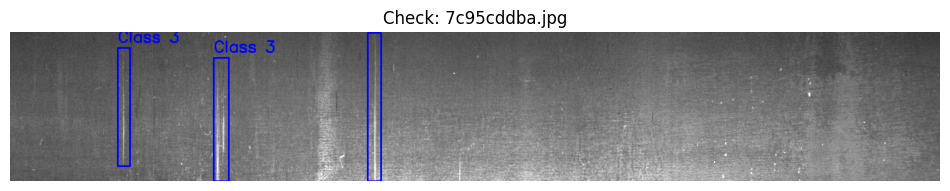

In [3]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# ================= 配置路径 =================
# 根据你刚才整理的目录结构
base_dir = "/root/autodl-tmp/exp1/SEVERSTAL_YOLO"
img_dir = os.path.join(base_dir, "images/train")
label_dir = os.path.join(base_dir, "labels/train") 
# 注意：如果你之前的脚本把txt生成在了 train_images 同级目录下，请检查一下
# 如果找不到，试着改成 os.path.join(base_dir, "train_images") 看看

# Severstal 的类别名
class_names = ['1', '2', '3', '4']
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)] # 红绿蓝黄

def view_random_sample():
    if not os.path.exists(label_dir):
        print(f"❌ 错误：找不到标签目录 {label_dir}")
        print("请检查 process_severstal.py 生成的标签到底去哪了？")
        return

    # 获取所有 txt 文件
    txt_files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
    
    if not txt_files:
        print("❌ 错误：标签目录是空的！数据转换可能没成功。")
        return

    # 随机挑一个有内容的标签文件
    while True:
        txt_file = random.choice(txt_files)
        txt_path = os.path.join(label_dir, txt_file)
        
        # 读一下文件，确保不是空的（Severstal有很多图没缺陷）
        with open(txt_path, 'r') as f:
            lines = f.readlines()
        if len(lines) > 0:
            break
    
    # 找到对应的图片
    img_name = txt_file.replace('.txt', '.jpg')
    img_path = os.path.join(img_dir, img_name)
    
    if not os.path.exists(img_path):
        print(f"❌ 错误：有标签 {txt_file} 但找不到图片 {img_name}")
        return

    print(f"👀 正在检查: {img_name}")
    print(f"📝 标签内容: {lines}")

    # 读取图片
    img = cv2.imread(img_path)
    if img is None:
        print("❌ 无法读取图片")
        return
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    # 画框
    for line in lines:
        parts = line.strip().split()
        cls_id = int(parts[0])
        x_center, y_center, bbox_w, bbox_h = map(float, parts[1:])

        # 反归一化：把 0~1 的小数变成像素坐标
        xmin = int((x_center - bbox_w / 2) * w)
        ymin = int((y_center - bbox_h / 2) * h)
        xmax = int((x_center + bbox_w / 2) * w)
        ymax = int((y_center + bbox_h / 2) * h)

        # 画矩形和文字
        color = colors[cls_id]
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, 2)
        cv2.putText(img, f"Class {class_names[cls_id]}", (xmin, ymin - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    # 显示
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Check: {img_name}")
    plt.show()

# 运行检查
view_random_sample()

In [1]:
import os
import shutil
import pandas as pd
import numpy as np
import cv2
from tqdm import tqdm

# ================= 配置区域 =================
RAW_CSV_PATH = "/root/autodl-tmp/severstal/train.csv"
RAW_IMG_DIR = "/root/autodl-tmp/severstal/train_images"
OUTPUT_PATH = "/root/autodl-tmp/exp1/SEVERSTAL_YOLO"

# ✅ 修正点：Severstal 图片是 1600(宽) x 256(高)
# Numpy reshape 顺序是 (高, 宽)
IMG_H = 256
IMG_W = 1600
# ===========================================

def rle2bbox(rle):
    """解码 RLE 并返回归一化 bbox"""
    try:
        runs = np.array([int(x) for x in rle.split()])
        starts, lengths = runs[0::2], runs[1::2]
        # 创建展平的 mask
        mask = np.zeros(IMG_H * IMG_W, dtype=np.uint8)
        for s, l in zip(starts, lengths):
            mask[s - 1 : s + l - 1] = 1
        
        # ✅ 修正点：使用 (H, W) 进行 reshape
        mask = mask.reshape((IMG_H, IMG_W), order='F') 

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        bboxes = []
        for c in contours:
            x, y, w, h = cv2.boundingRect(c)
            # 归一化: x除以宽, y除以高
            x_c = (x + w / 2) / IMG_W
            y_c = (y + h / 2) / IMG_H
            w_n = w / IMG_W
            h_n = h / IMG_H
            
            # 再次检查边界，确保不越界
            if x_c > 1 or y_c > 1: 
                continue 
                
            bboxes.append([x_c, y_c, w_n, h_n])
        return bboxes
    except Exception as e:
        return []

def main():
    if os.path.exists(OUTPUT_PATH): shutil.rmtree(OUTPUT_PATH)
    os.makedirs(os.path.join(OUTPUT_PATH, 'images/train'), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_PATH, 'labels/train'), exist_ok=True)

    print("⏳ 读取 CSV...")
    df = pd.read_csv(RAW_CSV_PATH)
    df['ClassId'] = df['ClassId'] - 1 # 0-3
    groups = df.groupby('ImageId')
    
    all_imgs = [x for x in os.listdir(RAW_IMG_DIR) if x.endswith('.jpg')]
    print(f"🚀 开始修正处理 {len(all_imgs)} 张图片...")
    
    for img_name in tqdm(all_imgs):
        shutil.copy(os.path.join(RAW_IMG_DIR, img_name), os.path.join(OUTPUT_PATH, 'images/train', img_name))
        
        lines = []
        if img_name in groups.groups:
            img_df = groups.get_group(img_name)
            for _, row in img_df.iterrows():
                if pd.notna(row['EncodedPixels']):
                    bboxes = rle2bbox(row['EncodedPixels'])
                    for b in bboxes:
                        lines.append(f"{row['ClassId']} {b[0]:.6f} {b[1]:.6f} {b[2]:.6f} {b[3]:.6f}")
        
        with open(os.path.join(OUTPUT_PATH, 'labels/train', img_name.replace('.jpg','.txt')), 'w') as f:
            f.write('\n'.join(lines))

    # 生成配置文件
    yaml_content = f"path: {OUTPUT_PATH}\ntrain: images/train\nval: images/train\nnc: 4\nnames: ['1', '2', '3', '4']"
    with open(os.path.join(OUTPUT_PATH, "severstal.yaml"), 'w') as f:
        f.write(yaml_content)
    print("✅ 修正版数据处理完毕！")

if __name__ == "__main__":
    main()

⏳ 读取 CSV...
🚀 开始修正处理 12568 张图片...


100%|██████████| 12568/12568 [00:32<00:00, 387.14it/s]


✅ 修正版数据处理完毕！
